# Does the copper price move against the US dollar?

**Business question (whole project):** who needs copper, who supplies it, and what does the price do when they collide?
This notebook covers the first hypothesis.

**H1.** Copper gets cheaper when the dollar gets stronger, and dearer when it gets weaker. Copper is priced in US dollars, so a stronger dollar makes it dearer for buyers who hold other currencies.

**What is tested.** Monthly changes (log returns), not price levels, because two trending price levels can look related by chance.
The dollar is measured two ways: the broad dollar index (2006 onward) and the euro (1999 onward).
For the euro I use *euros per dollar*, the inverse of the "USD per euro" rate, so that **up always means a stronger dollar** in both measures. H1 then predicts a **negative** link for both.

**Data (all in the database, built from the sources register):**
copper and aluminium from the World Bank Pink Sheet (S02), USD per euro from FRED (S16), broad dollar index from FRED (S17), 10-year US yield from FRED (S18), US inflation from FRED (S04).
Everything is a **monthly average** (the dollar index is the mean of its daily values), so all variables are measured the same way.

**Read this first.** These are historical associations in one sample. They are not forecasts, not investment advice, and a correlation is not proof that one thing causes the other.
Run `python copper_database/build_db.py --raw .` first so that `copper.db` exists.

In [1]:
import sqlite3
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings("ignore")

# Two colours from the validated reference palette, used in a fixed order (blue first, orange second)
BLUE, ORANGE, INK, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#dcdcd8"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#8a8984", "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 10,
    "text.color": INK, "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 1.8, "legend.frameon": False,
})



def pad_right(ax, first, last, years=4):
    """Time axis that ends exactly at the last data point, with a right margin outside the plot for the end labels
    (so the axis never shows years after the data, which could look like a forecast)."""
    ax.set_xlim(first, last)
    ax.xaxis.set_major_locator(mdates.YearLocator(years))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.figure.subplots_adjust(right=0.78)


def show(df, nd=3):
    """Round for display; p-values below 0.001 are shown as <0.001 instead of 0.000."""
    out = df.copy()
    for c in out.columns:
        if c == "p" or c.endswith(" p"):
            out[c] = out[c].map(lambda v: "<0.001" if v < 0.001 else f"{v:.3f}")
    return out.round(nd)


con = sqlite3.connect("../copper_database/copper.db")
panel = pd.read_sql("SELECT * FROM mart_monthly_panel", con, parse_dates=["month"]).set_index("month")
chg = pd.read_sql("SELECT * FROM mart_monthly_changes", con, parse_dates=["month"]).set_index("month")

# Euros per dollar: up = stronger dollar. Exact inverse of USD per euro, so the log return is just the sign flipped.
chg["usd_vs_eur_logret_m"] = -chg["usd_per_eur_logret_m"]
chg["copper_logret_m"] = chg["copper_usd_logret_m"]

print(f"Panel: {len(panel)} months, {panel.index.min():%Y-%m} to {panel.index.max():%Y-%m}")

Panel: 332 months, 1999-01 to 2026-08


In [2]:
# Sample sizes: how many monthly changes each comparison can use
pairs = {
    "Copper vs euro (1999-02 on)": ["copper_logret_m", "usd_vs_eur_logret_m"],
    "Copper vs dollar index (2006-02 on)": ["copper_logret_m", "dollar_index_logret_m"],
    "Dollar index with 10-year rate change": ["copper_logret_m", "dollar_index_logret_m", "us10y_chg_pp_m"],
}
sizes = pd.DataFrame({"months": {k: len(chg[v].dropna()) for k, v in pairs.items()}})
sizes["first month"] = [chg[v].dropna().index.min().strftime("%Y-%m") for v in pairs.values()]
sizes["last month"] = [chg[v].dropna().index.max().strftime("%Y-%m") for v in pairs.values()]
sizes

,months,first month,last month
Copper vs euro (1999-02 on),331,1999-02,2026-08
Copper vs dollar index (2006-02 on),247,2006-02,2026-08
Dollar index with 10-year rate change,247,2006-02,2026-08


## 1. The two series side by side (context only, not a test)

Both lines are indexed to January 2006 = 100, so one axis is enough.

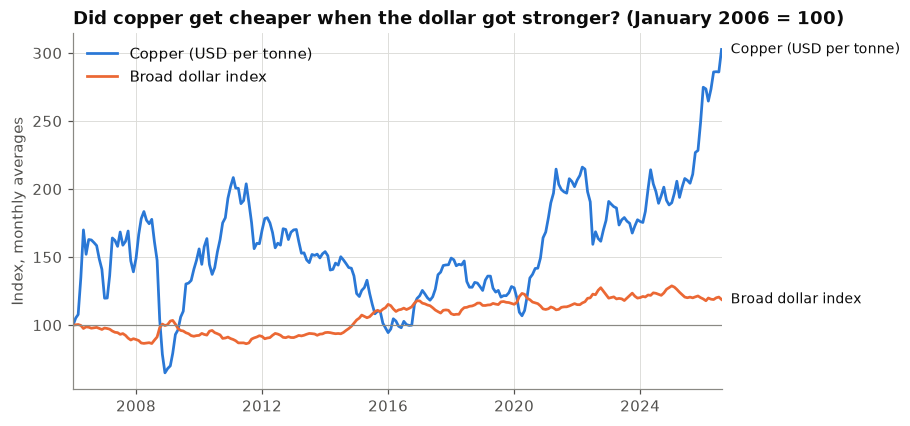

In [3]:
base = panel.loc["2006-01-01"]
idx = pd.DataFrame({
    "Copper (USD per tonne)": panel["copper_usd_t_avg"] / base["copper_usd_t_avg"] * 100,
    "Broad dollar index": panel["dollar_index_avg"] / base["dollar_index_avg"] * 100,
}).loc["2006-01-01":]

fig, ax = plt.subplots()
ax.plot(idx.index, idx.iloc[:, 0], color=BLUE, label=idx.columns[0])
ax.plot(idx.index, idx.iloc[:, 1], color=ORANGE, label=idx.columns[1])
ax.axhline(100, color="#8a8984", lw=0.8)
ax.set_title("Did copper get cheaper when the dollar got stronger? (January 2006 = 100)")
ax.set_ylabel("Index, monthly averages")
for col, c in zip(idx.columns, [BLUE, ORANGE]):
    ax.annotate(col, (idx.index[-1], idx[col].iloc[-1]), xytext=(6, 0), textcoords="offset points", color=INK, va="center", fontsize=9)
pad_right(ax, idx.index[0], idx.index[-1])
ax.legend(loc="upper left")
plt.show()

The picture is context only. Both series wander for years at a time, so their levels say little about monthly behaviour. The tests below use monthly changes.

## 2. Test A: do monthly changes in copper and the dollar move together?

For each pair: Pearson and Spearman correlation (Spearman uses ranks and is less sensitive to extreme months such as 2008 and 2020).
The 95% interval for Pearson comes from a **block bootstrap** (blocks of 6 months, 5,000 resamples, fixed seed), which respects the fact that neighbouring months are not independent.
H1 predicts a negative correlation.

In [4]:
def block_boot_ci(x, y, block=6, n_boot=5000, seed=42):
    """Moving-block bootstrap 95% interval for the Pearson correlation."""
    rng = np.random.default_rng(seed)
    n = len(x)
    k = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for i in range(n_boot):
        starts = rng.integers(0, n - block + 1, size=k)
        take = (starts[:, None] + np.arange(block)).ravel()[:n]
        out[i] = np.corrcoef(x[take], y[take])[0, 1]
    return np.percentile(out, [2.5, 97.5])


def corr_row(label, d, xcol, ycol):
    x, y = d[xcol].to_numpy(), d[ycol].to_numpy()
    r, p = stats.pearsonr(x, y)
    rho, p_s = stats.spearmanr(x, y)
    lo, hi = block_boot_ci(x, y)
    return {"comparison": label, "months": len(d), "pearson r": r, "95% interval low": lo, "95% interval high": hi,
            "pearson p": p, "spearman rho": rho, "spearman p": p_s}


d_eur = chg[["copper_logret_m", "usd_vs_eur_logret_m"]].dropna()
d_dxy = chg[["copper_logret_m", "dollar_index_logret_m"]].dropna()
d_eur_same = d_eur.loc[d_dxy.index.min():]  # euro on the same months as the dollar index, for a fair comparison

corr_tbl = pd.DataFrame([
    corr_row("Copper vs euros per dollar, 1999-02 to 2026-08", d_eur, "copper_logret_m", "usd_vs_eur_logret_m"),
    corr_row("Copper vs euros per dollar, 2006-02 to 2026-08", d_eur_same, "copper_logret_m", "usd_vs_eur_logret_m"),
    corr_row("Copper vs broad dollar index, 2006-02 to 2026-08", d_dxy, "copper_logret_m", "dollar_index_logret_m"),
]).set_index("comparison")
show(corr_tbl)

,months,pearson r,95% interval low,95% interval high,pearson p,spearman rho,spearman p
comparison,,,,,,,
"Copper vs euros per dollar, 1999-02 to 2026-08",331,-0.322,-0.440,-0.184,<0.001,-0.280,<0.001
"Copper vs euros per dollar, 2006-02 to 2026-08",247,-0.405,-0.523,-0.249,<0.001,-0.346,<0.001
"Copper vs broad dollar index, 2006-02 to 2026-08",247,-0.560,-0.674,-0.403,<0.001,-0.519,<0.001


## 3. Test B: how big is the link? (regression with a control)

Regression of monthly copper log return on the monthly log change of the dollar (both measures), then adding the change in the 10-year US yield (in percentage points) as a control, since rates and the dollar tend to move together.
Standard errors are Newey-West (HAC, 3 lags), which allows for neighbouring months being related.
A coefficient of -0.5 would mean: in months when the dollar rose 1%, copper tended to be 0.5% lower.

In [5]:
def ols_row(label, d, y, xs):
    X = sm.add_constant(d[xs])
    m = sm.OLS(d[y], X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    ci = m.conf_int()
    rows = []
    for v in xs:
        rows.append({"model": label, "variable": v, "coefficient": m.params[v], "std error (HAC)": m.bse[v],
                     "95% interval low": ci.loc[v, 0], "95% interval high": ci.loc[v, 1], "p": m.pvalues[v],
                     "R squared": m.rsquared, "months": int(m.nobs)})
    return rows


d1 = chg[["copper_logret_m", "usd_vs_eur_logret_m"]].dropna()
d2 = chg[["copper_logret_m", "dollar_index_logret_m", "us10y_chg_pp_m"]].dropna()
d3 = chg[["copper_logret_m", "usd_vs_eur_logret_m", "us10y_chg_pp_m"]].dropna().loc[d2.index.min():]
reg_tbl = pd.DataFrame(
    ols_row("1. euro only, 1999-02 on", d1, "copper_logret_m", ["usd_vs_eur_logret_m"])
    + ols_row("2. dollar index only, 2006-02 on", d2, "copper_logret_m", ["dollar_index_logret_m"])
    + ols_row("3. dollar index + 10-year rate, 2006-02 on", d2, "copper_logret_m", ["dollar_index_logret_m", "us10y_chg_pp_m"])
    + ols_row("4. euro + 10-year rate, 2006-02 on", d3, "copper_logret_m", ["usd_vs_eur_logret_m", "us10y_chg_pp_m"])
).set_index(["model", "variable"])
show(reg_tbl)

coefficient  \
model                                      variable                             
1. euro only, 1999-02 on                   usd_vs_eur_logret_m         -0.908   
2. dollar index only, 2006-02 on           dollar_index_logret_m       -2.771   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m       -2.866   
                                           us10y_chg_pp_m               0.100   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m         -1.475   
                                           us10y_chg_pp_m               0.111   

                                                                  std error (HAC)  \
model                                      variable                                 
1. euro only, 1999-02 on                   usd_vs_eur_logret_m              0.242   
2. dollar index only, 2006-02 on           dollar_index_logret_m            0.446   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m            0.440   
                                           us10y_chg_pp_m                   0.023   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m              0.294   
                                           us10y_chg_pp_m                   0.028   

                                                                  95% interval low  \
model                                      variable                                  
1. euro only, 1999-02 on                   usd_vs_eur_logret_m              -1.382   
2. dollar index only, 2006-02 on           dollar_index_logret_m            -3.645   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m            -3.727   
                                           us10y_chg_pp_m                    0.054   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m              -2.051   
                                           us10y_chg_pp_m                    0.057   

                                                                  95% interval high  \
model                                      variable                                   
1. euro only, 1999-02 on                   usd_vs_eur_logret_m               -0.434   
2. dollar index only, 2006-02 on           dollar_index_logret_m             -1.896   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m             -2.004   
                                           us10y_chg_pp_m                     0.146   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m               -0.900   
                                           us10y_chg_pp_m                     0.166   

                                                                       p  \
model                                      variable                        
1. euro only, 1999-02 on                   usd_vs_eur_logret_m    <0.001   
2. dollar index only, 2006-02 on           dollar_index_logret_m  <0.001   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m  <0.001   
                                           us10y_chg_pp_m         <0.001   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m    <0.001   
                                           us10y_chg_pp_m         <0.001   

                                                                  R squared  \
model                                      variable                           
1. euro only, 1999-02 on                   usd_vs_eur_logret_m        0.104   
2. dollar index only, 2006-02 on           dollar_index_logret_m      0.314   
3. dollar index + 10-year rate, 2006-02 on dollar_index_logret_m      0.414   
                                           us10y_chg_pp_m             0.414   
4. euro + 10-year rate, 2006-02 on         usd_vs_eur_logret_m        0.286   
                                           us10y_chg_pp_m             0.286   

                                                                  months  
model                            

## 4. Is the link stable over time?

A single number for 20 years can hide a link that changed sign. Two checks: a rolling 36-month correlation, and a split at the start of 2015.
**The split date was chosen before looking at results** (a round mid-point of the sample), not tuned to them.

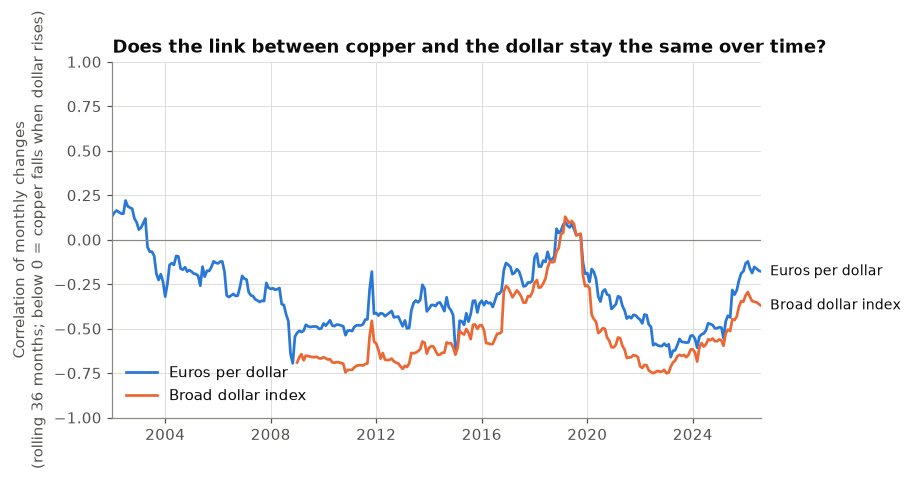

In [6]:
roll = pd.DataFrame({
    "Euros per dollar": chg["copper_logret_m"].rolling(36).corr(chg["usd_vs_eur_logret_m"]),
    "Broad dollar index": chg["copper_logret_m"].rolling(36).corr(chg["dollar_index_logret_m"]),
}).dropna(how="all")

fig, ax = plt.subplots()
ax.plot(roll.index, roll["Euros per dollar"], color=BLUE, label="Euros per dollar")
ax.plot(roll.index, roll["Broad dollar index"], color=ORANGE, label="Broad dollar index")
ax.axhline(0, color="#8a8984", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title("Does the link between copper and the dollar stay the same over time?")
ax.set_ylabel("Correlation of monthly changes\n(rolling 36 months; below 0 = copper falls when dollar rises)")
pad_right(ax, roll.index[0], roll.index[-1])
for col in roll.columns:
    s = roll[col].dropna()
    ax.annotate(col, (s.index[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", fontsize=9, va="center")
ax.legend(loc="lower left")
plt.show()

In [7]:
periods = {"1999-02 to 2014-12": ("1999-02-01", "2014-12-01"), "2015-01 to 2026-08": ("2015-01-01", "2026-08-01"),
           "2006-02 to 2014-12": ("2006-02-01", "2014-12-01")}
rows = []
for name, (a, b) in periods.items():
    for lab, col in [("euros per dollar", "usd_vs_eur_logret_m"), ("broad dollar index", "dollar_index_logret_m")]:
        d = chg.loc[a:b, ["copper_logret_m", col]].dropna()
        if col == "dollar_index_logret_m" and a < "2006-02-01":
            continue
        if col == "usd_vs_eur_logret_m" and name == "2006-02 to 2014-12":
            continue
        rows.append(corr_row(f"{lab}, {name}", d, "copper_logret_m", col))
split_tbl = pd.DataFrame(rows).set_index("comparison")
split_tbl[["months", "pearson r", "95% interval low", "95% interval high", "spearman rho"]].round(3)

,months,pearson r,95% interval low,95% interval high,spearman rho
comparison,,,,,
"euros per dollar, 1999-02 to 2014-12",191,-0.319,-0.466,-0.134,-0.269
"euros per dollar, 2015-01 to 2026-08",140,-0.333,-0.477,-0.099,-0.289
"broad dollar index, 2015-01 to 2026-08",140,-0.473,-0.633,-0.233,-0.470
"broad dollar index, 2006-02 to 2014-12",107,-0.636,-0.768,-0.443,-0.579


## 5. Timing: does the dollar move first, or copper?

Correlation of copper's change this month with the dollar's change *k* months earlier (k > 0: the dollar leads) or later (k < 0: copper leads).
A real "dollar drives copper" story would show a link at k > 0, not only at k = 0.

In [8]:
rows = []
for k in range(-2, 4):
    for lab, col in [("euros per dollar", "usd_vs_eur_logret_m"), ("broad dollar index", "dollar_index_logret_m")]:
        d = pd.DataFrame({"c": chg["copper_logret_m"], "x": chg[col].shift(k)}).dropna()
        if col == "dollar_index_logret_m":
            d = d.loc["2006-02-01":]
        r, p = stats.pearsonr(d["c"], d["x"])
        rows.append({"dollar measure": lab, "dollar leads by k months": k, "pearson r": r, "p": p, "months": len(d)})
lag_tbl = pd.DataFrame(rows)
lag_tbl.pivot(index="dollar leads by k months", columns="dollar measure", values="pearson r").round(3)

dollar measure,broad dollar index,euros per dollar
dollar leads by k months,,
-2,-0.123,-0.003
-1,-0.274,-0.155
0,-0.560,-0.322
1,-0.259,-0.181
2,-0.128,-0.100
3,-0.068,-0.121


## 6. What does copper cost a European buyer?

Copper in euros is the dollar price divided by USD per euro. For a European buyer the euro price is what matters.
In logs this is exact: **euro change = dollar change + change in euros per dollar**. So a stronger dollar (more euros per dollar) pushes the euro price up even if the dollar price is flat.
Indexed to January 1999 = 100.

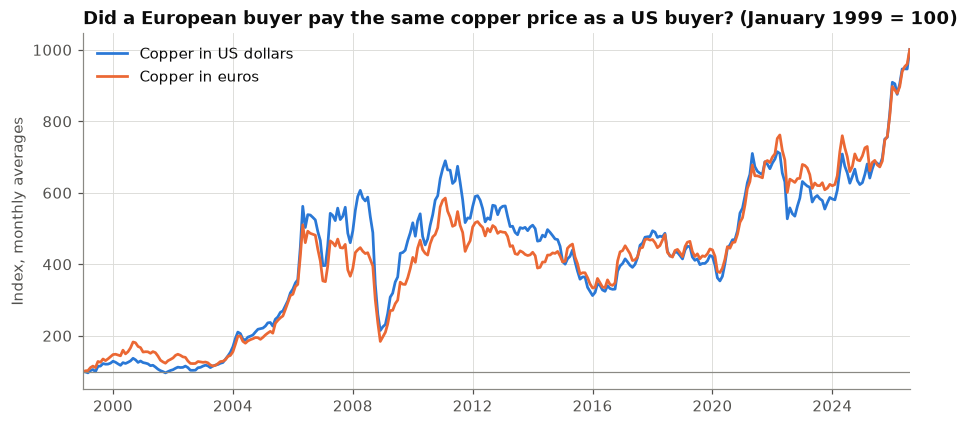

In [9]:
b99 = panel.loc["1999-01-01"]
eu = pd.DataFrame({
    "Copper in US dollars": panel["copper_usd_t_avg"] / b99["copper_usd_t_avg"] * 100,
    "Copper in euros": panel["copper_eur_t_avg"] / b99["copper_eur_t_avg"] * 100,
})
fig, ax = plt.subplots()
ax.plot(eu.index, eu["Copper in US dollars"], color=BLUE, label="Copper in US dollars")
ax.plot(eu.index, eu["Copper in euros"], color=ORANGE, label="Copper in euros")
ax.axhline(100, color="#8a8984", lw=0.8)
ax.set_title("Did a European buyer pay the same copper price as a US buyer? (January 1999 = 100)")
ax.set_ylabel("Index, monthly averages")
pad_right(ax, eu.index[0], eu.index[-1], years=4)
ax.figure.subplots_adjust(right=0.96)  # the two lines end together, so the legend replaces end labels
ax.legend(loc="upper left")
plt.show()

In [10]:
windows = {"since 1999-01": "1999-01-01", "since 2006-01": "2006-01-01", "last 5 years (since 2021-08)": "2021-08-01",
           "last 12 months (since 2025-08)": "2025-08-01"}
last = panel.index.max()
rows = []
for name, start in windows.items():
    a, z = panel.loc[start], panel.loc[last]
    rows.append({"window": name,
                 "copper in USD, % change": (z["copper_usd_t_avg"] / a["copper_usd_t_avg"] - 1) * 100,
                 "copper in EUR, % change": (z["copper_eur_t_avg"] / a["copper_eur_t_avg"] - 1) * 100,
                 "euros per dollar, % change": ((1 / z["usd_per_eur_avg"]) / (1 / a["usd_per_eur_avg"]) - 1) * 100})
cum_tbl = pd.DataFrame(rows).set_index("window")
cum_tbl.round(1)

,"copper in USD, % change","copper in EUR, % change","euros per dollar, % change"
window,,,
since 1999-01,901.1,900.9,-0.0
since 2006-01,202.6,216.5,4.6
last 5 years (since 2021-08),52.9,55.2,1.5
last 12 months (since 2025-08),48.1,48.8,0.5


In [11]:
# Monthly variation: euro change = dollar change + currency change, so Var(EUR) = Var(USD) + Var(FX) + 2 Cov(USD, FX)
dd = chg[["copper_usd_logret_m", "usd_vs_eur_logret_m", "copper_eur_logret_m"]].dropna() * 100
sd = dd.std()
cov = dd["copper_usd_logret_m"].cov(dd["usd_vs_eur_logret_m"])
dec_tbl = pd.DataFrame({
    "measure": ["monthly std dev, copper in USD (%)", "monthly std dev, euros per dollar (%)", "monthly std dev, copper in EUR (%)",
                "variance, copper in USD", "variance, euros per dollar", "2 x covariance (USD copper, euros per dollar)",
                "variance, copper in EUR (= sum of the three above)", "months"],
    "value": [sd["copper_usd_logret_m"], sd["usd_vs_eur_logret_m"], sd["copper_eur_logret_m"],
              dd["copper_usd_logret_m"].var(), dd["usd_vs_eur_logret_m"].var(), 2 * cov, dd["copper_eur_logret_m"].var(), len(dd)],
}).set_index("measure")
dec_tbl.round(3)

,value
measure,
"monthly std dev, copper in USD (%)",6.075
"monthly std dev, euros per dollar (%)",2.157
"monthly std dev, copper in EUR (%)",5.754
"variance, copper in USD",36.905
"variance, euros per dollar",4.654
"2 x covariance (USD copper, euros per dollar)",-8.453
"variance, copper in EUR (= sum of the three above)",33.106
months,331.000


## 7. Sensitivity: the missing US inflation month

US inflation (CPI) has no value for October 2025: the federal shutdown stopped data collection (BLS, source S19), and BLS says November 2025 was computed against carried-forward October prices.
The database keeps October as empty and never fills it. The main tests above use **nominal** copper, which does not need CPI, so they include those months.
Two checks: (a) repeat Test A and B leaving out October and November 2025; (b) use **inflation-adjusted** copper, which has to leave those two months out.

In [12]:
def beta_corr(d, xcol, ycol="y"):
    m = sm.OLS(d[ycol], sm.add_constant(d[[xcol]])).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    return m.params[xcol], m.bse[xcol], np.corrcoef(d[xcol], d[ycol])[0, 1], int(m.nobs)


skip = pd.to_datetime(["2025-10-01", "2025-11-01"])
rows = []
for lab, col in [("broad dollar index", "dollar_index_logret_m"), ("euros per dollar", "usd_vs_eur_logret_m")]:
    base_d = chg[["copper_logret_m", col]].dropna().rename(columns={"copper_logret_m": "y"})
    if col == "dollar_index_logret_m":
        base_d = base_d.loc["2006-02-01":]
    variants = {
        "nominal copper, all months": base_d,
        "nominal copper, without 2025-10 and 2025-11": base_d.drop(skip, errors="ignore"),
        "inflation-adjusted copper (2025-10 and 2025-11 empty)": chg[["copper_real_usd_logret_m", col]].dropna()
            .rename(columns={"copper_real_usd_logret_m": "y"}).loc[base_d.index.min():],
    }
    for vname, d in variants.items():
        b, se, r, n = beta_corr(d, col)
        rows.append({"dollar measure": lab, "version": vname, "coefficient": b, "std error (HAC)": se, "pearson r": r, "months": n})
sens_tbl = pd.DataFrame(rows).set_index(["dollar measure", "version"])
sens_tbl.round(3)

coefficient  \
dollar measure     version                                                           
broad dollar index nominal copper, all months                               -2.771   
                   nominal copper, without 2025-10 and 2025-11              -2.783   
                   inflation-adjusted copper (2025-10 and 2025-11 ...       -2.713   
euros per dollar   nominal copper, all months                               -0.908   
                   nominal copper, without 2025-10 and 2025-11              -0.913   
                   inflation-adjusted copper (2025-10 and 2025-11 ...       -0.888   

                                                                       std error (HAC)  \
dollar measure     version                                                               
broad dollar index nominal copper, all months                                    0.446   
                   nominal copper, without 2025-10 and 2025-11                   0.445   
                   inflation-adjusted copper (2025-10 and 2025-11 ...            0.431   
euros per dollar   nominal copper, all months                                    0.242   
                   nominal copper, without 2025-10 and 2025-11                   0.242   
                   inflation-adjusted copper (2025-10 and 2025-11 ...            0.236   

                                                                       pearson r  \
dollar measure     version                                                         
broad dollar index nominal copper, all months                             -0.560   
                   nominal copper, without 2025-10 and 2025-11            -0.564   
                   inflation-adjusted copper (2025-10 and 2025-11 ...     -0.559   
euros per dollar   nominal copper, all months                             -0.322   
                   nominal copper, without 2025-10 and 2025-11            -0.324   
                   inflation-adjusted copper (2025-10 and 2025-11 ...     -0.321   

                                                                       months  
dollar measure     version                                                     
broad dollar index nominal copper, all months                             247  
                   nominal copper, without 2025-10 and 2025-11            245  
                   inflation-adjusted copper (2025-10 and 2025-11 ...     245  
euros per dollar   nominal copper, all months                             331  
                   nominal copper, without 2025-10 and 2025-11            329  
                   inflation-adjusted copper (2025-10 and 2025-11 ...     329

## 8. Robustness: month-end values instead of monthly averages

Monthly averages smooth prices and can slightly distort correlations. Here the same test uses **month-end values** from the daily data: the LME copper cash price and the broad dollar index, each on the last trading day of the month.
For a fair comparison the averages-based version is repeated on exactly the same months, using the LME cash price for copper in both versions.
Limits: this covers the dollar index only (EUR/USD is available only as a monthly average), and LME data ends in July 2025, so the sample is 2006-02 to 2025-06.
Only derived changes are shown, not the LME series itself.

In [13]:
me_cols = ["copper_lme_cash_avg_logret_m", "dollar_index_logret_m", "copper_lme_cash_month_end_logret_m", "dollar_index_month_end_logret_m"]
me = chg[me_cols].dropna()
HAVE_LME = len(me) > 0
if not HAVE_LME:
    # A copy of the project without the licensed LME data (it is never published): show the stored result of this check instead.
    me_tbl = pd.read_csv("../results/res_dollar_month_end_check.csv").set_index("version")
    print("The LME data is not in this copy of the project. Showing the stored result of the month-end check from results/res_dollar_month_end_check.csv; "
          "reproducing it needs LME historical data that you download yourself.")
else:
    versions = {
        "monthly averages (LME copper, dollar index)": me[[me_cols[0], me_cols[1]]].set_axis(["y", "x"], axis=1),
        "month-end values (LME copper, dollar index)": me[[me_cols[2], me_cols[3]]].set_axis(["y", "x"], axis=1),
    }
    rows = []
    for name, d in versions.items():
        r = corr_row(name, d, "y", "x")
        m_ = sm.OLS(d["y"], sm.add_constant(d[["x"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
        ci = m_.conf_int().loc["x"]
        rows.append({"version": name, "months": r["months"], "pearson r": r["pearson r"], "95% interval low": r["95% interval low"],
                     "95% interval high": r["95% interval high"], "spearman rho": r["spearman rho"],
                     "coefficient": m_.params["x"], "coefficient low": ci[0], "coefficient high": ci[1]})
    me_tbl = pd.DataFrame(rows).set_index("version")
show(me_tbl)

,months,pearson r,95% interval low,95% interval high,spearman rho,coefficient,coefficient low,coefficient high
version,,,,,,,,
"monthly averages (LME copper, dollar index)",233,-0.559,-0.679,-0.401,-0.517,-2.773,-3.666,-1.880
"month-end values (LME copper, dollar index)",233,-0.523,-0.654,-0.377,-0.479,-2.259,-3.083,-1.434


## 9. Summary of results
The numbers below are printed from the tables above, so they always match the code.

In [14]:
def f(x, nd=2):
    return f"{x:.{nd}f}"


c1, c2, c3 = corr_tbl.iloc[0], corr_tbl.iloc[1], corr_tbl.iloc[2]
print("Test A, correlation of monthly changes (95% block-bootstrap interval):")
for name, row in [("euros per dollar 1999-02 on", c1), ("euros per dollar 2006-02 on", c2), ("broad dollar index 2006-02 on", c3)]:
    print(f"  {name}: r = {f(row['pearson r'])} [{f(row['95% interval low'])}, {f(row['95% interval high'])}], Spearman {f(row['spearman rho'])}, n = {int(row['months'])}")
print("Test B, regression coefficient on the dollar (HAC 95% interval):")
for (m, v), row in reg_tbl.iterrows():
    if v != "us10y_chg_pp_m":
        print(f"  {m}: {f(row['coefficient'])} [{f(row['95% interval low'])}, {f(row['95% interval high'])}], R squared {f(row['R squared'], 3)}")
print("Stability, correlation by period:")
for name, row in split_tbl.iterrows():
    print(f"  {name}: r = {f(row['pearson r'])} [{f(row['95% interval low'])}, {f(row['95% interval high'])}], n = {int(row['months'])}")
print("Rolling 36-month correlation (min, max, last):")
for c in roll.columns:
    s_ = roll[c].dropna()
    print(f"  {c}: min {f(s_.min())}, max {f(s_.max())}, last {f(s_.iloc[-1])} ({s_.index[-1]:%Y-%m})")
print("Timing, correlation when the dollar leads by k months (k = -1, 0, 1):")
for lab in ["broad dollar index", "euros per dollar"]:
    v = lag_tbl[lag_tbl["dollar measure"] == lab].set_index("dollar leads by k months")["pearson r"]
    print(f"  {lab}: k=-1 {f(v[-1])}, k=0 {f(v[0])}, k=1 {f(v[1])}")
print("Euro buyer, monthly std dev (%): copper in USD {}, copper in EUR {}".format(f(dec_tbl.loc["monthly std dev, copper in USD (%)", "value"]), f(dec_tbl.loc["monthly std dev, copper in EUR (%)", "value"])))
print("Month-end check (LME copper vs dollar index, same months):")
for v, row in me_tbl.iterrows():
    print(f"  {v}: r = {f(row['pearson r'])} [{f(row['95% interval low'])}, {f(row['95% interval high'])}], coefficient {f(row['coefficient'])} [{f(row['coefficient low'])}, {f(row['coefficient high'])}], n = {int(row['months'])}")
print("Sensitivity (coefficient, dollar index / euros per dollar):")
for (lab, ver), row in sens_tbl.iterrows():
    print(f"  {lab}, {ver}: {f(row['coefficient'])} (n = {int(row['months'])})")

Test A, correlation of monthly changes (95% block-bootstrap interval):
  euros per dollar 1999-02 on: r = -0.32 [-0.44, -0.18], Spearman -0.28, n = 331
  euros per dollar 2006-02 on: r = -0.41 [-0.52, -0.25], Spearman -0.35, n = 247
  broad dollar index 2006-02 on: r = -0.56 [-0.67, -0.40], Spearman -0.52, n = 247
Test B, regression coefficient on the dollar (HAC 95% interval):
  1. euro only, 1999-02 on: -0.91 [-1.38, -0.43], R squared 0.104
  2. dollar index only, 2006-02 on: -2.77 [-3.65, -1.90], R squared 0.314
  3. dollar index + 10-year rate, 2006-02 on: -2.87 [-3.73, -2.00], R squared 0.414
  4. euro + 10-year rate, 2006-02 on: -1.48 [-2.05, -0.90], R squared 0.286
Stability, correlation by period:
  euros per dollar, 1999-02 to 2014-12: r = -0.32 [-0.47, -0.13], n = 191
  euros per dollar, 2015-01 to 2026-08: r = -0.33 [-0.48, -0.10], n = 140
  broad dollar index, 2015-01 to 2026-08: r = -0.47 [-0.63, -0.23], n = 140
  broad dollar index, 2006-02 to 2014-12: r = -0.64 [-0.77, -

## 10. What this does and does not show
*(written after reading the results above)*

**What the data show in this sample (monthly changes, 1999 or 2006 to August 2026)**

- **Copper and the dollar moved in opposite directions, as H1 predicts.** Broad dollar index: correlation -0.56 (95% interval -0.67 to -0.40, 247 months). Euros per dollar: -0.32 (-0.44 to -0.18, 331 months); on the same 247 months as the dollar index it is -0.41 (-0.52 to -0.25). Rank correlations point the same way (-0.52, -0.28 and -0.35), so a few extreme months do not drive the result.
- **Size of the link.** In months when the broad dollar index rose 1%, copper was on average 2.8% lower (interval -3.65 to -1.90). For the euro alone the figure is 0.9% (interval -1.38 to -0.43). The dollar index alone accounts for about 31% of the variation in monthly copper changes (R squared 0.31); adding the change in the 10-year US yield lifts that to 0.41 and leaves the dollar coefficient almost unchanged (-2.87). Most of the monthly variation in copper is still unexplained.
- **The link is not constant.** The rolling 36-month correlation with the broad index ranges from -0.75 to +0.13 (euro: -0.70 to +0.22), and it was close to zero around 2019. At the end of the sample it is weaker than its typical level (-0.37 for the index, -0.18 for the euro). Splitting at 2015 gives -0.64 before and -0.47 after for the index, with overlapping intervals, so a weaker link is suggested but not firmly shown. For the euro the two periods are the same (-0.32 and -0.33).
- **No clear lead.** The link is strongest in the same month (-0.56 for the index). One month before or after it is about -0.26 and -0.27, nearly symmetric. The dollar does not visibly move first. Because every series is a monthly average, the order of events inside a month cannot be seen at all.
- **For a European buyer,** the dollar price and the euro price ended almost the same since January 1999 (+901% in both, because the euro-dollar rate was about the same at both ends). Since January 2006 copper rose 203% in dollars and 217% in euros (dollar 4.6% stronger against the euro). Month to month, the euro price varies slightly less (standard deviation 5.75%) than the dollar price (6.07%): copper tends to fall when the dollar rises, which cushions a European buyer a little.
- **The missing US inflation month does not change the result.** Leaving out October and November 2025, or using inflation-adjusted copper (which must leave them out), moves the dollar-index coefficient from -2.77 to -2.78 and -2.71, and the euro coefficient from -0.91 to -0.91 and -0.89.
- **Month-end values give the same picture, a little weaker.** On the same 233 months (2006-02 to 2025-06), with LME copper and the dollar index both taken at month-end, the correlation is -0.52 (interval -0.65 to -0.38) against -0.56 (-0.68 to -0.40) with monthly averages. The coefficient is -2.26 (-3.08 to -1.43) against -2.77 (-3.67 to -1.88). The intervals overlap, so the conclusion stands, but the size of the link depends somewhat on how prices are measured, and the averaged version looks a little stronger.

**What this does not show**

- **It does not show that the dollar moves copper.** Both could react to the same news (for example global growth or risk appetite). This notebook does not test those drivers, and the missing lead above fits a common reaction as well as a one-way effect.
- **It is not a forecast** and not investment advice. The link changed over time and may change again.
- **The month-end check covers the dollar index only, for 2006-02 to 2025-06.** EUR/USD exists only as a monthly average, so the euro result was not checked this way, and LME data ends in July 2025.
- **The 2008-09 and 2020 episodes were not tested separately.** The rank correlations are similar, which suggests they do not drive the result, but this was not isolated.
- **One sample.** About 21 years for the dollar index and 27 for the euro. The 10-year yield coefficient was included as a control and is not interpreted here.

## 11. Save the derived results
Results go to `results/` as CSV files (derived results only) and into the database as `res_` tables. A database rebuild reloads them from `results/`.

In [15]:
import os

os.makedirs("../results", exist_ok=True)


def save(df, name):
    out = df.reset_index()
    out.to_csv(f"../results/{name}.csv", index=False)
    out.to_sql(name, con, if_exists="replace", index=False)


save(corr_tbl, "res_dollar_correlations")
save(reg_tbl, "res_dollar_regressions")
save(split_tbl, "res_dollar_stability_by_period")
save(roll.round(6), "res_dollar_rolling_correlation_36m")
save(lag_tbl, "res_dollar_lead_lag")
save(cum_tbl, "res_copper_eur_vs_usd_cumulative")
save(dec_tbl, "res_copper_eur_variance_split")
save(sens_tbl, "res_dollar_cpi_sensitivity")
if HAVE_LME:  # without the licensed LME data the stored file is kept as it is
    save(me_tbl, "res_dollar_month_end_check")
con.commit()
con.close()
print("Saved 9 result tables" if HAVE_LME else "Saved 8 result tables (the month-end check file is kept from the licensed-data run)")

Saved 9 result tables
